<a href="https://colab.research.google.com/github/RASIUT/ML/blob/main/Classification/Gradient_Boosting_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing Libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##Importing Datasets

In [13]:
df = pd.read_csv("/content/Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [15]:
X = df.iloc[:, 2:-1].values
y = df.iloc[:, -1].values

##Splitting the data into train and test split

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

##Feature Scaling

In [20]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

##Training the Gradient Boosting Classification

In [21]:
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

##Predicting a new result

In [26]:
print(model.predict(sc.transform([[30, 87000]])))

[0]


##Predicting test set results

In [27]:
y_pred = model.predict(X_test)

y_pred_vector = y_pred.reshape(len(y_pred), 1)
y_test_vector = y_test.reshape(len(y_test), 1)

np.concatenate((y_pred_vector, y_test_vector), axis = 1)

array([[0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0,

##Confusion Matrix and accuracy score

In [28]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_vector, y_pred_vector)
print(cm)

[[64  4]
 [ 5 27]]


Text(0.5, 1.0, 'Confusion Matrix')

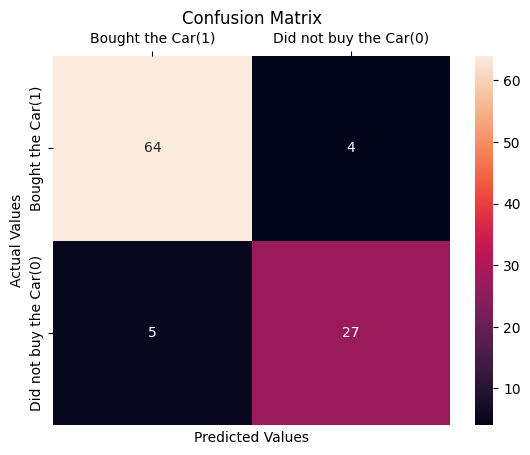

In [30]:
import seaborn as sns
sns.heatmap(cm, annot=True, xticklabels=["Bought the Car(1)", "Did not buy the Car(0)"], yticklabels=["Bought the Car(1)", "Did not buy the Car(0)"])

plt.tick_params(axis='x', which='both', bottom=False, top=True, labelbottom=False, labeltop = True)

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

plt.title("Confusion Matrix")

In [33]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test_vector, y_pred_vector))

0.91
